# Time-Series Forecasting with ARIMA / SARIMA

## Project Overview

This project develops an end-to-end time-series forecasting pipeline for analyzing historical demand patterns and generating future demand predictions.

The analysis covers:

- Historical demand trends
- Time-series decomposition
- Seasonality analysis
- Stationarity testing using the Augmented Dickey-Fuller (ADF) test
- Differencing
- ARIMA / SARIMA model selection
- Forecast evaluation using MAPE and RMSE
- 30-day future demand forecasting

### Dataset

The dataset contains daily demand observations along with marketing-event and holiday indicators.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Load Dataset

In [3]:
DATA_PATH = "../data/daily-demand-series.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,date,demand,marketing_event,holiday
0,2026-06-01,118,0,0
1,2026-06-02,121,0,0
2,2026-06-03,125,0,0
3,2026-06-04,123,0,0
4,2026-06-05,137,1,0


## 2. Initial Data Inspection

In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (30, 4)

Column Information:
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   date             30 non-null     str  
 1   demand           30 non-null     int64
 2   marketing_event  30 non-null     int64
 3   holiday          30 non-null     int64
dtypes: int64(3), str(1)
memory usage: 1.1 KB
None

Missing Values:
date               0
demand             0
marketing_event    0
holiday            0
dtype: int64

Duplicate Rows: 0


In [5]:
df.describe()

,demand,marketing_event,holiday
count,30.000000,30.000000,30.000000
mean,142.100000,0.266667,0.133333
std,13.839848,0.449776,0.345746
min,118.000000,0.000000,0.000000
25%,132.500000,0.000000,0.000000
50%,142.000000,0.000000,0.000000
75%,150.250000,0.750000,0.000000
max,174.000000,1.000000,1.000000


## 3. DateTime Preprocessing

In [6]:
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date")

df = df.set_index("date")

df.head()

,demand,marketing_event,holiday
date,,,
2026-06-01,118,0,0
2026-06-02,121,0,0
2026-06-03,125,0,0
2026-06-04,123,0,0
2026-06-05,137,1,0


In [7]:
print("Start Date:", df.index.min())
print("End Date:", df.index.max())
print("Frequency:", pd.infer_freq(df.index))

Start Date: 2026-06-01 00:00:00
End Date: 2026-06-30 00:00:00
Frequency: D


In [8]:
df[["demand", "marketing_event", "holiday"]].head(10)

,demand,marketing_event,holiday
date,,,
2026-06-01,118,0,0
2026-06-02,121,0,0
2026-06-03,125,0,0
2026-06-04,123,0,0
2026-06-05,137,1,0
2026-06-06,151,1,0
2026-06-07,143,0,1
2026-06-08,126,0,0
2026-06-09,129,0,0


In [9]:
print(df.index.is_monotonic_increasing)

True


## 4. Historical Demand Trend

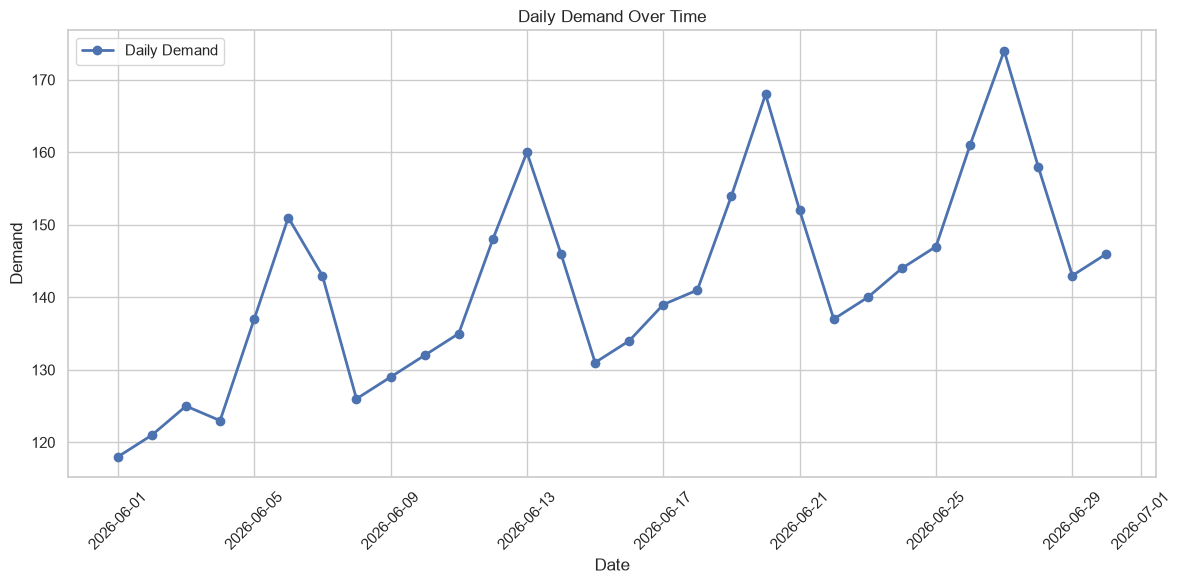

In [10]:
plt.figure(figsize=(12, 6))

plt.plot(
    df.index,
    df["demand"],
    marker="o",
    linewidth=2,
    label="Daily Demand"
)

plt.title("Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## 5. Trend Analysis

A rolling mean is used to smooth short-term fluctuations and reveal the underlying demand trend.

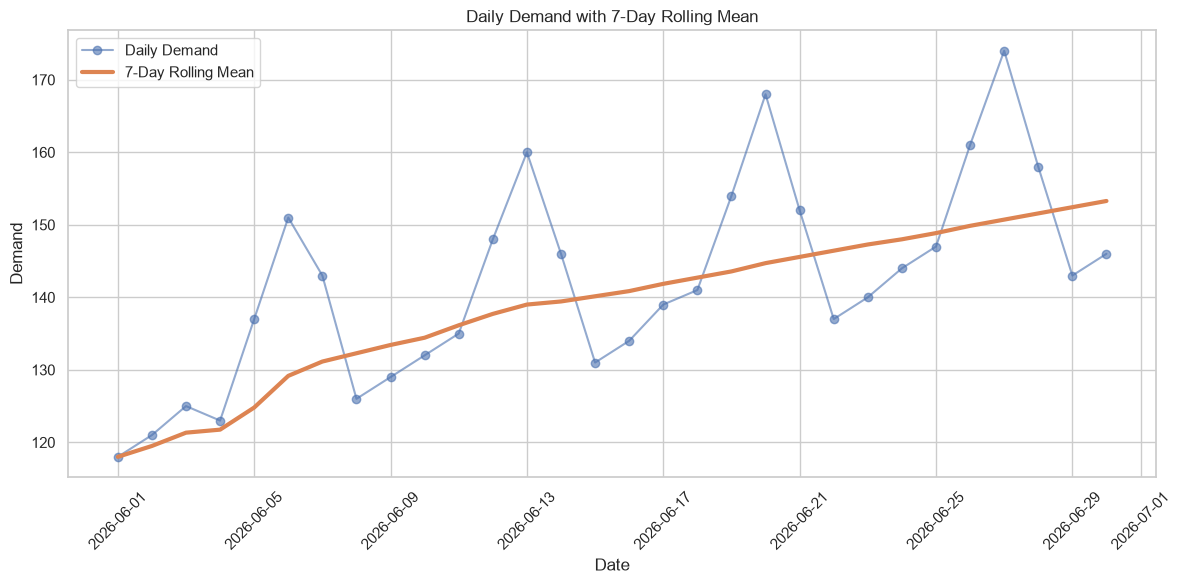

In [11]:
rolling_window = 7

df["rolling_mean_7d"] = df["demand"].rolling(
    window=rolling_window,
    min_periods=1
).mean()

plt.figure(figsize=(12, 6))

plt.plot(
    df.index,
    df["demand"],
    marker="o",
    alpha=0.6,
    label="Daily Demand"
)

plt.plot(
    df.index,
    df["rolling_mean_7d"],
    linewidth=3,
    label="7-Day Rolling Mean"
)

plt.title("Daily Demand with 7-Day Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Weekly Seasonality Analysis

Daily demand is grouped by day of the week to identify potential weekly seasonal patterns.

In [12]:
df["day_of_week"] = df.index.day_name()

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekly_pattern = (
    df.groupby("day_of_week")["demand"]
    .mean()
    .reindex(weekday_order)
)

weekly_pattern

day_of_week
Monday       131.00
Tuesday      134.00
Wednesday    135.00
Thursday     136.50
Friday       150.00
Saturday     163.25
Sunday       149.75
Name: demand, dtype: float64

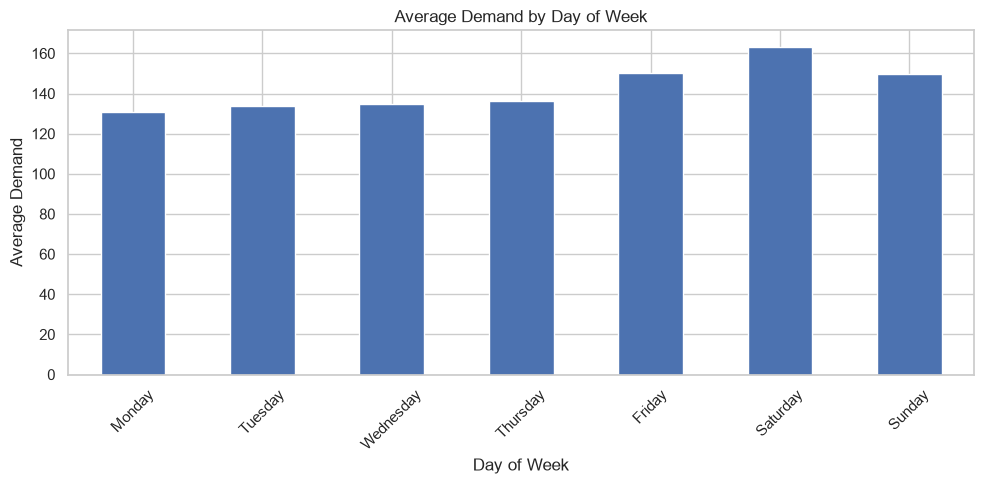

In [13]:
plt.figure(figsize=(10, 5))

weekly_pattern.plot(
    kind="bar",
    rot=45
)

plt.title("Average Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Demand")
plt.tight_layout()
plt.show()

## 7. Demand During Marketing Events

The effect of marketing events on demand is explored by comparing event and non-event days.

In [14]:
event_demand = (
    df.groupby("marketing_event")["demand"]
    .agg(["count", "mean", "min", "max"])
)

event_demand

,count,mean,min,max
marketing_event,,,,
0,22,136.818182,118,158
1,8,156.625000,137,174


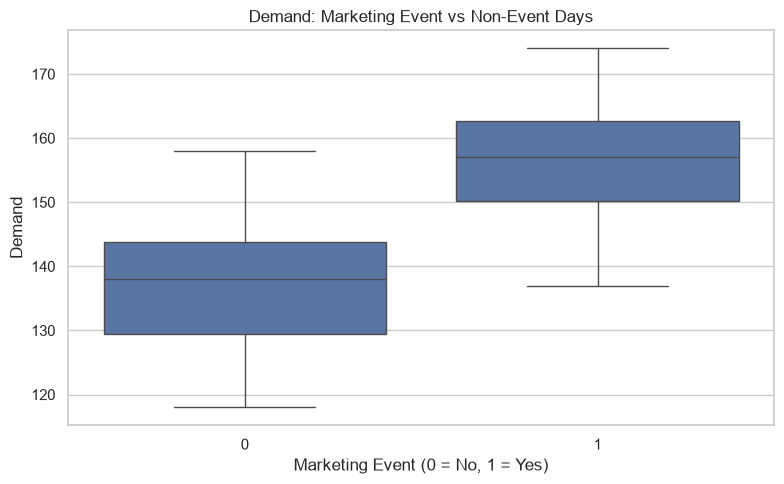

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="marketing_event",
    y="demand"
)

plt.title("Demand: Marketing Event vs Non-Event Days")
plt.xlabel("Marketing Event (0 = No, 1 = Yes)")
plt.ylabel("Demand")
plt.tight_layout()
plt.show()

## 8. Time-Series Decomposition

The demand series is decomposed into:

- Observed component
- Trend component
- Seasonal component
- Residual component

A weekly period of 7 days is used because the observations are daily.

In [16]:
demand_series = df["demand"].asfreq("D")

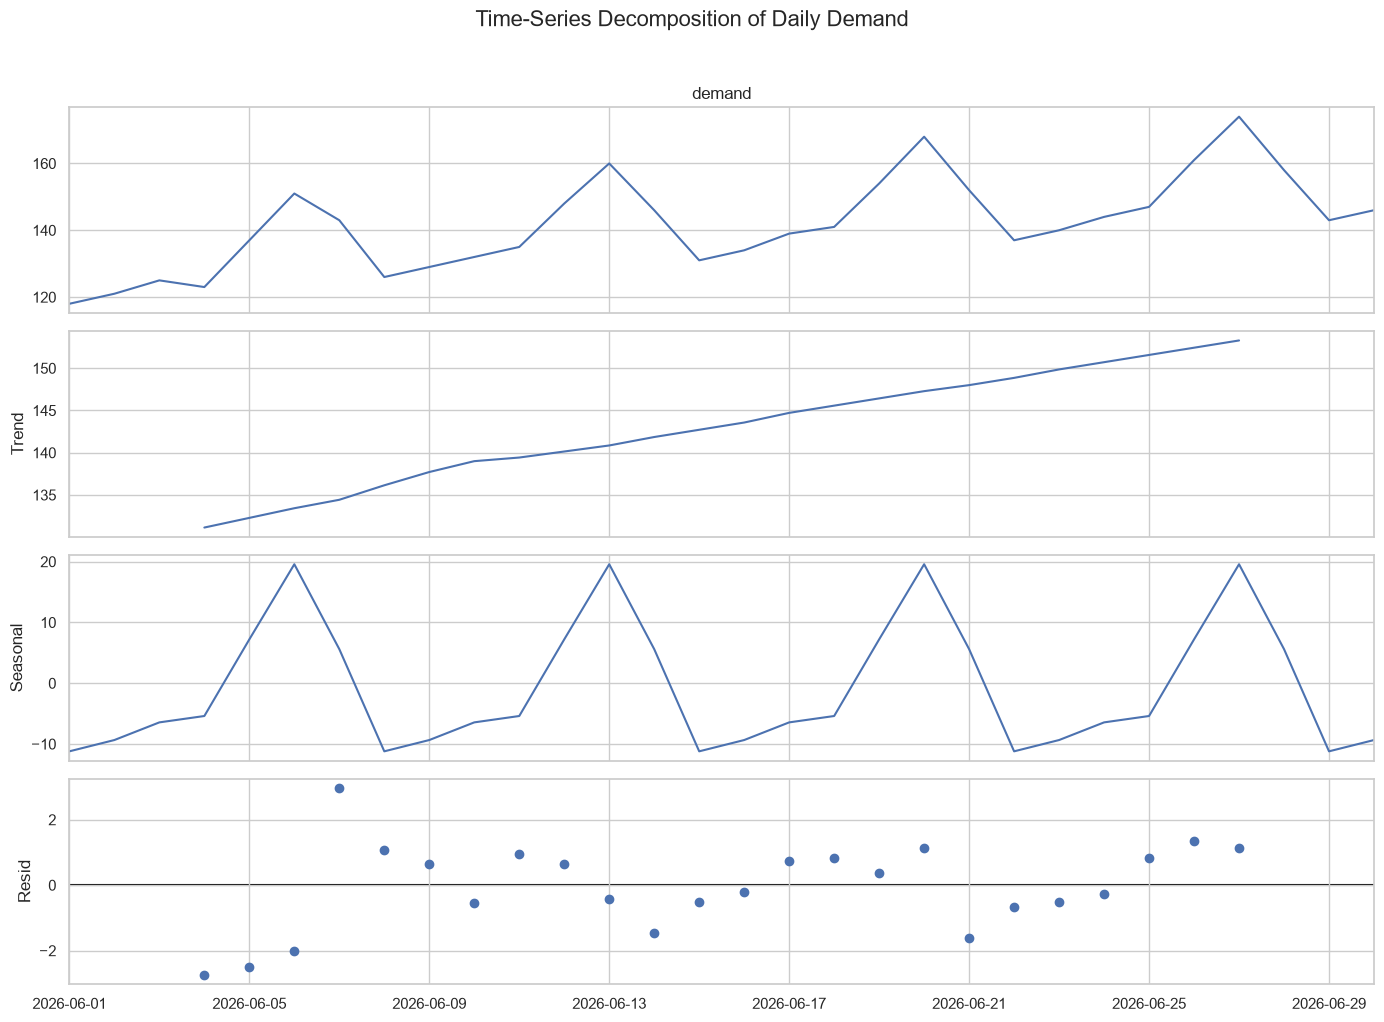

In [17]:
decomposition = seasonal_decompose(
    demand_series,
    model="additive",
    period=7
)

fig = decomposition.plot()

fig.set_size_inches(14, 10)

fig.suptitle(
    "Time-Series Decomposition of Daily Demand",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

In [18]:
decomposition_components = pd.DataFrame({
    "Observed": decomposition.observed,
    "Trend": decomposition.trend,
    "Seasonal": decomposition.seasonal,
    "Residual": decomposition.resid
})

decomposition_components.head(10)

,Observed,Trend,Seasonal,Residual
date,,,,
2026-06-01,118.0,NaN,-11.204082,NaN
2026-06-02,121.0,NaN,-9.346939,NaN
2026-06-03,125.0,NaN,-6.442177,NaN
2026-06-04,123.0,131.142857,-5.394558,-2.748299
2026-06-05,137.0,132.285714,7.212585,-2.498299
2026-06-06,151.0,133.428571,19.569728,-1.998299
2026-06-07,143.0,134.428571,5.605442,2.965986
2026-06-08,126.0,136.142857,-11.204082,1.061224
2026-06-09,129.0,137.714286,-9.346939,0.632653


In [19]:
decomposition_components.describe()

,Observed,Trend,Seasonal,Residual
count,30.000000,24.000000,30.000000,24.000000
mean,142.100000,142.976190,-0.685034,-0.034014
std,13.839848,6.634275,10.502025,1.354443
min,118.000000,131.142857,-11.204082,-2.748299
25%,132.500000,138.678571,-9.346939,-0.581633
50%,142.000000,143.142857,-5.394558,0.067177
75%,150.250000,148.214286,6.810799,0.858844
max,174.000000,153.285714,19.569728,2.965986


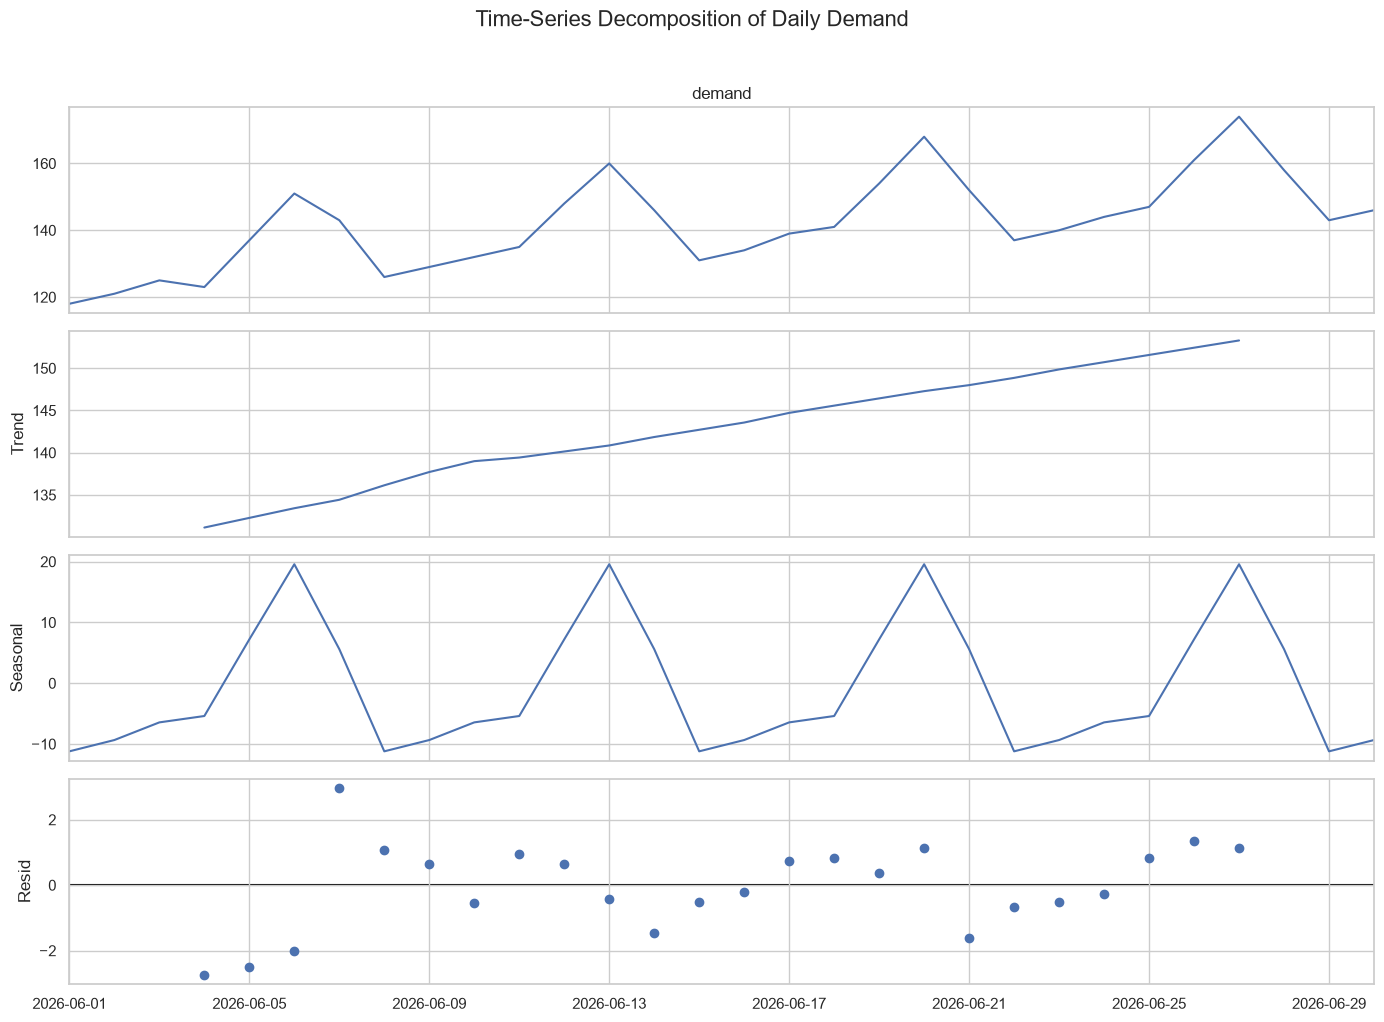

In [20]:
fig = decomposition.plot()

fig.set_size_inches(14, 10)

fig.suptitle(
    "Time-Series Decomposition of Daily Demand",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

plt.savefig(
    "../outputs/time_series_decomposition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 9. Stationarity Analysis

Stationarity is an important assumption for ARIMA-based forecasting.

The Augmented Dickey-Fuller (ADF) test is used to determine whether the demand series is stationary.

In [22]:
# Augmented Dickey-Fuller Test

adf_result = adfuller(df["demand"].dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

if adf_result[1] <= 0.05:
    print("\nConclusion: The demand series is stationary.")
else:
    print("\nConclusion: The demand series is not stationary.")

ADF Statistic: -0.9038698873856338
p-value: 0.7866953368372341

Critical Values:
1%: -3.769732625845229
5%: -3.005425537190083
10%: -2.6425009917355373

Conclusion: The demand series is not stationary.


## 10. First-Order Differencing

The original demand series is non-stationary according to the ADF test.

First-order differencing is applied to remove potential trend effects and make the series more suitable for ARIMA modeling.

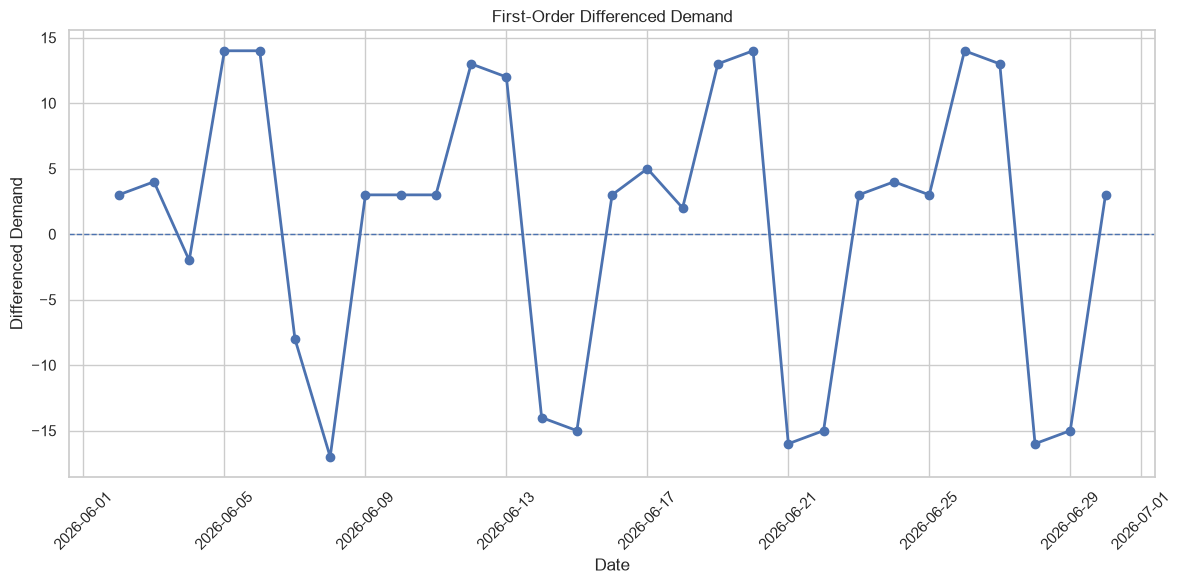

In [23]:
# Apply first-order differencing

df["demand_diff"] = df["demand"].diff()

plt.figure(figsize=(12, 6))
plt.plot(
    df.index,
    df["demand_diff"],
    marker="o",
    linewidth=2
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("First-Order Differenced Demand")
plt.xlabel("Date")
plt.ylabel("Differenced Demand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
# ADF test after first-order differencing

adf_diff_result = adfuller(df["demand_diff"].dropna())

print("ADF Statistic:", adf_diff_result[0])
print("p-value:", adf_diff_result[1])

print("\nCritical Values:")
for key, value in adf_diff_result[4].items():
    print(f"{key}: {value}")

if adf_diff_result[1] <= 0.05:
    print("\nConclusion: The differenced demand series is stationary.")
else:
    print("\nConclusion: The differenced demand series is still not stationary.")

ADF Statistic: -2.233624012735415
p-value: 0.19426893706635578

Critical Values:
1%: -3.769732625845229
5%: -3.005425537190083
10%: -2.6425009917355373

Conclusion: The differenced demand series is still not stationary.


## 11. Second-Order Differencing Check

The first-order differenced series did not pass the ADF stationarity test at the 5% significance level.

Because the dataset contains only 30 observations, repeated differencing should be used cautiously. A second-order difference is therefore evaluated as a diagnostic rather than being automatically selected.

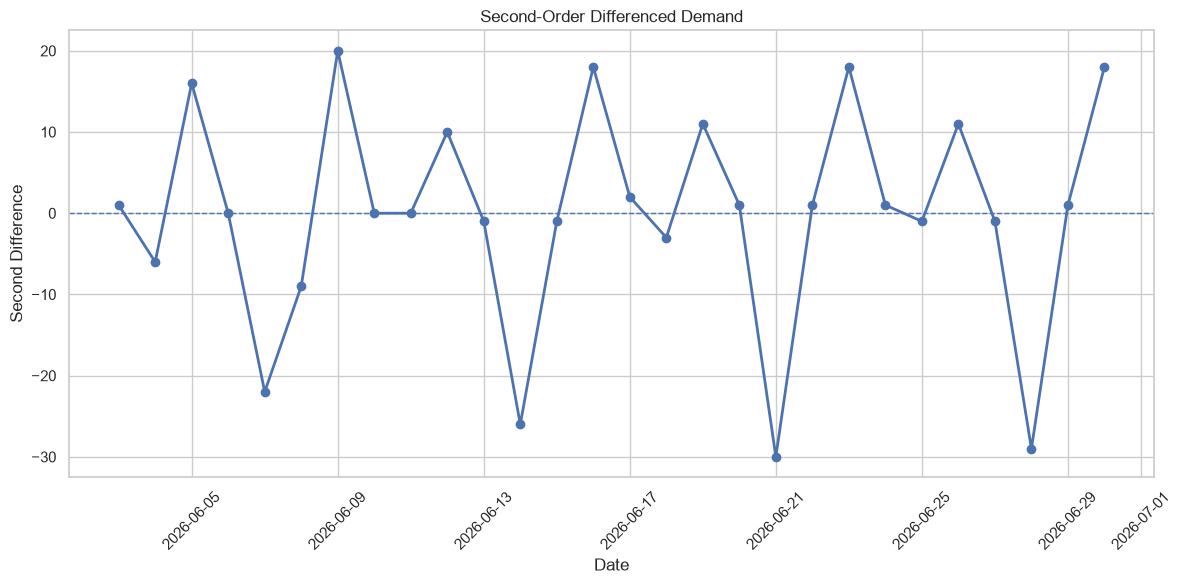

In [25]:
# Apply second-order differencing

df["demand_diff2"] = df["demand_diff"].diff()

plt.figure(figsize=(12, 6))
plt.plot(
    df.index,
    df["demand_diff2"],
    marker="o",
    linewidth=2
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Second-Order Differenced Demand")
plt.xlabel("Date")
plt.ylabel("Second Difference")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
# ADF test after second-order differencing

adf_diff2_result = adfuller(df["demand_diff2"].dropna())

print("ADF Statistic:", adf_diff2_result[0])
print("p-value:", adf_diff2_result[1])

print("\nCritical Values:")
for key, value in adf_diff2_result[4].items():
    print(f"{key}: {value}")

if adf_diff2_result[1] <= 0.05:
    print("\nConclusion: The second-order differenced series is stationary.")
else:
    print("\nConclusion: The second-order differenced series is still not stationary.")

ADF Statistic: -15.186988638006357
p-value: 6.085057742440609e-28

Critical Values:
1%: -3.769732625845229
5%: -3.005425537190083
10%: -2.6425009917355373

Conclusion: The second-order differenced series is stationary.


## 12. Train-Test Split

The dataset is split chronologically so that future observations are never used to train the forecasting model.

The final 20% of observations are reserved as the test set.

In [27]:
# Chronological train-test split

demand_series = df["demand"].asfreq("D")

split_point = int(len(demand_series) * 0.8)

train = demand_series.iloc[:split_point]
test = demand_series.iloc[split_point:]

print("Total observations:", len(demand_series))
print("Training observations:", len(train))
print("Testing observations:", len(test))

print("\nTraining period:")
print(train.index.min(), "to", train.index.max())

print("\nTesting period:")
print(test.index.min(), "to", test.index.max())

Total observations: 30
Training observations: 24
Testing observations: 6

Training period:
2026-06-01 00:00:00 to 2026-06-24 00:00:00

Testing period:
2026-06-25 00:00:00 to 2026-06-30 00:00:00


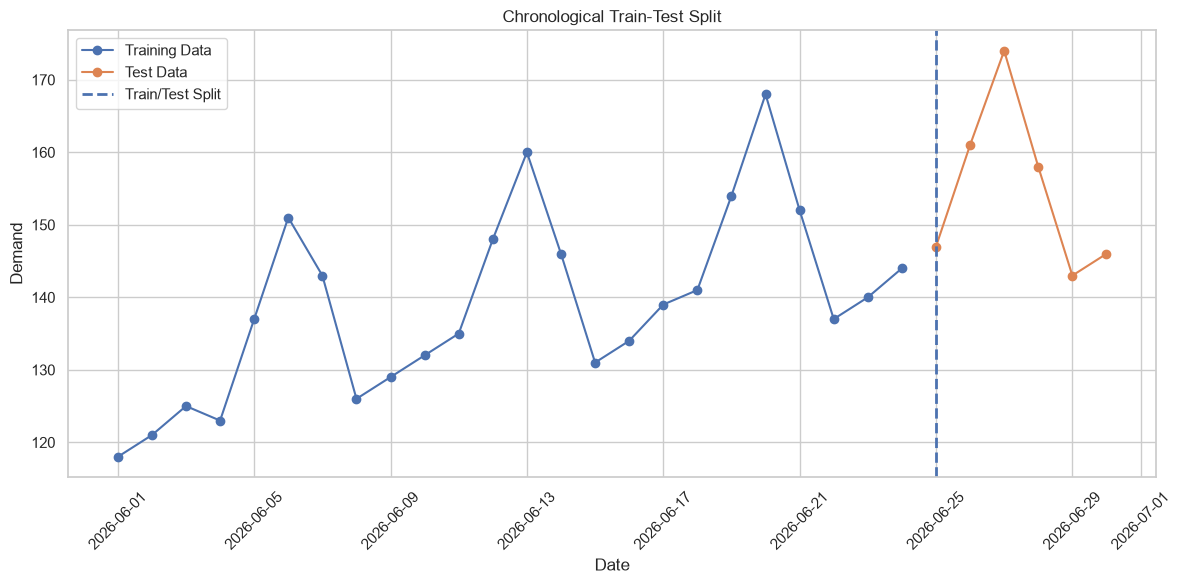

In [28]:
plt.figure(figsize=(12, 6))

plt.plot(train.index, train, marker="o", label="Training Data")
plt.plot(test.index, test, marker="o", label="Test Data")

plt.axvline(
    test.index[0],
    linestyle="--",
    linewidth=2,
    label="Train/Test Split"
)

plt.title("Chronological Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 13. Naive Forecast Baseline

A naive forecasting model uses the last observed training value as the prediction for every test observation.

This provides a simple benchmark against which the ARIMA models can be evaluated.

In [29]:
# Naive forecast baseline

naive_forecast = pd.Series(
    train.iloc[-1],
    index=test.index
)

print("Last training demand:", train.iloc[-1])
print("\nNaive Forecast:")
print(naive_forecast)

Last training demand: 144

Naive Forecast:
date
2026-06-25    144
2026-06-26    144
2026-06-27    144
2026-06-28    144
2026-06-29    144
2026-06-30    144
Freq: D, dtype: int64


In [30]:
# Evaluate naive baseline

naive_rmse = np.sqrt(mean_squared_error(test, naive_forecast))
naive_mape = np.mean(
    np.abs((test - naive_forecast) / test)
) * 100

print(f"Naive Baseline RMSE: {naive_rmse:.4f}")
print(f"Naive Baseline MAPE: {naive_mape:.2f}%")

Naive Baseline RMSE: 15.2698
Naive Baseline MAPE: 6.80%


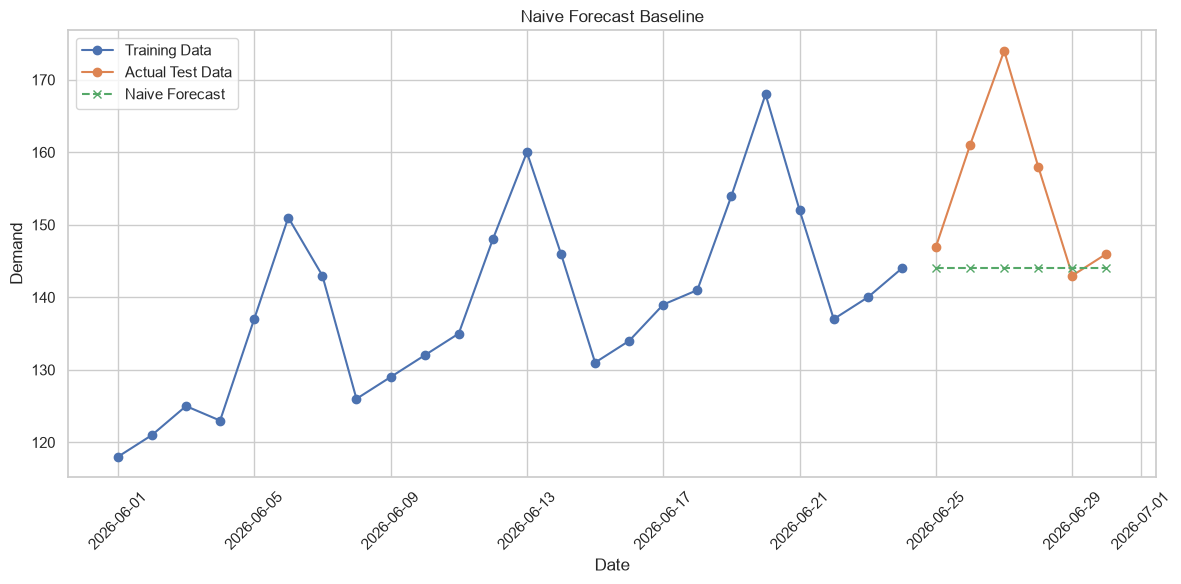

In [31]:
plt.figure(figsize=(12, 6))

plt.plot(train.index, train, marker="o", label="Training Data")
plt.plot(test.index, test, marker="o", label="Actual Test Data")
plt.plot(
    test.index,
    naive_forecast,
    marker="x",
    linestyle="--",
    label="Naive Forecast"
)

plt.title("Naive Forecast Baseline")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 14. ARIMA Model Selection

ARIMA models are evaluated using a small set of candidate `(p, d, q)` configurations.

The differencing order is initially set to `d=2` based on the stationarity analysis. Candidate models are compared using AIC, while final performance is evaluated on the held-out test set.

In [32]:
# Evaluate candidate ARIMA models

candidate_orders = [
    (0, 2, 0),
    (1, 2, 0),
    (0, 2, 1),
    (1, 2, 1),
    (2, 2, 0),
    (0, 2, 2),
    (2, 2, 1),
    (1, 2, 2),
    (2, 2, 2)
]

arima_results = []

for order in candidate_orders:
    try:
        model = ARIMA(train, order=order)
        fitted_model = model.fit()

        arima_results.append({
            "order": order,
            "AIC": fitted_model.aic
        })

    except Exception as e:
        print(f"ARIMA{order} failed: {e}")

arima_results_df = pd.DataFrame(arima_results)
arima_results_df = arima_results_df.sort_values("AIC").reset_index(drop=True)

arima_results_df

,order,AIC
0,"(2, 2, 2)",166.149906
1,"(0, 2, 2)",166.557610
2,"(1, 2, 2)",168.395875
3,"(2, 2, 0)",168.803106
4,"(2, 2, 1)",169.787320
5,"(0, 2, 0)",177.308812
6,"(1, 2, 1)",178.022156
7,"(0, 2, 1)",178.237207
8,"(1, 2, 0)",179.300022


## 15. ARIMA Test-Set Evaluation

The candidate models with the lowest AIC values are evaluated on the held-out test set.

Model performance is compared using RMSE and MAPE against the naive baseline.

In [33]:
# Evaluate top ARIMA candidates on the test set

top_orders = arima_results_df.head(5)["order"].tolist()

model_results = []

for order in top_orders:
    model = ARIMA(train, order=order)
    fitted_model = model.fit()

    forecast = fitted_model.forecast(steps=len(test))

    rmse = np.sqrt(mean_squared_error(test, forecast))
    mape = np.mean(np.abs((test - forecast) / test)) * 100

    model_results.append({
        "order": order,
        "AIC": fitted_model.aic,
        "RMSE": rmse,
        "MAPE": mape
    })

model_results_df = pd.DataFrame(model_results)
model_results_df = model_results_df.sort_values("RMSE").reset_index(drop=True)

model_results_df

,order,AIC,RMSE,MAPE
0,"(0, 2, 2)",166.557610,13.221210,6.444369
1,"(1, 2, 2)",168.395875,13.248900,6.448764
2,"(2, 2, 2)",166.149906,15.431580,7.009375
3,"(2, 2, 1)",169.787320,24.224222,13.920037
4,"(2, 2, 0)",168.803106,30.508309,18.111720


## 16. Best Model Forecast Visualization

ARIMA(0,2,2) achieved the lowest RMSE and MAPE among the evaluated candidates. Its predictions are compared with the actual test observations.

In [34]:
# Fit the best ARIMA model

best_order = (0, 2, 2)

best_model = ARIMA(train, order=best_order)
best_fitted_model = best_model.fit()

test_forecast = best_fitted_model.forecast(steps=len(test))

print("Best Model:", best_order)
print("\nForecast vs Actual:")
print(pd.DataFrame({
    "Actual": test,
    "Forecast": test_forecast
}))

Best Model: (0, 2, 2)

Forecast vs Actual:
            Actual    Forecast
2026-06-25     147  145.723115
2026-06-26     161  146.731091
2026-06-27     174  147.739067
2026-06-28     158  148.747043
2026-06-29     143  149.755019
2026-06-30     146  150.762995


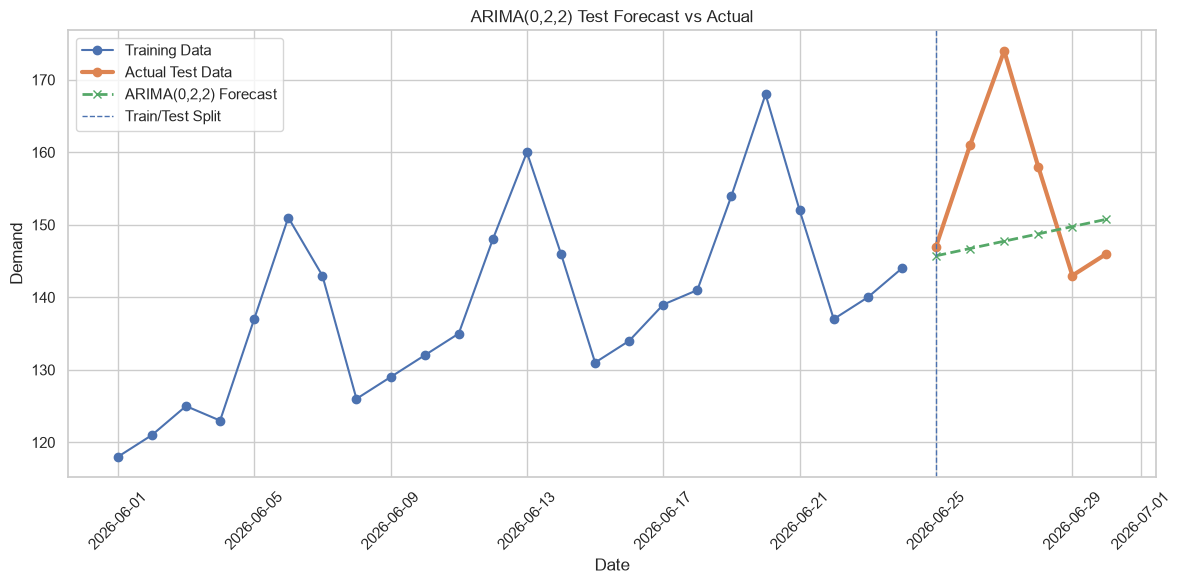

In [35]:
plt.figure(figsize=(12, 6))

plt.plot(train.index, train, marker="o", label="Training Data")
plt.plot(test.index, test, marker="o", linewidth=3, label="Actual Test Data")
plt.plot(
    test.index,
    test_forecast,
    marker="x",
    linestyle="--",
    linewidth=2,
    label="ARIMA(0,2,2) Forecast"
)

plt.axvline(
    test.index[0],
    linestyle="--",
    linewidth=1,
    label="Train/Test Split"
)

plt.title("ARIMA(0,2,2) Test Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Model Evaluation Summary

ARIMA(0,2,2) achieved the best test-set performance among the evaluated ARIMA candidates, with an RMSE of 13.22 and MAPE of 6.44%.

The model outperformed the naive baseline on both evaluation metrics. However, the forecast did not capture the sharp demand spike observed on June 26 and June 27. This limitation is expected given the very small dataset and the absence of sufficient historical observations to learn such irregular demand patterns.

Therefore, the results demonstrate the forecasting pipeline effectively, but should not be interpreted as production-level long-horizon forecasting performance.